<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
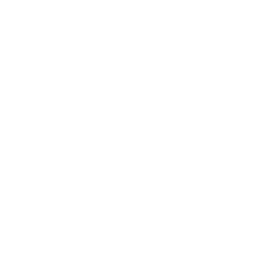
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Dokumentation des Schemas für genomische Variantenannotation</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioinformatik / Datenmanagement für klinische Genomik &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Dokumentation des Schemas VCF-artiger Variantenannotations-Datenmengen, die in einer klinischen Genomik-Pipeline verwendet werden. Mit PROC CONTENTS werden alle Annotationsfelder katalogisiert — genomische Koordinaten, Allelfrequenzen, vorhergesagte funktionale Effekte, ClinVar-Klassifikationen und Qualitätsmetriken —, um sicherzustellen, dass nachgelagerte Werkzeuge zur ACMG-Varianteninterpretation korrekt typisierte und beschriftete Eingaben erhalten. Rund 5,000 Variantendatensätze mit über 20 Annotationsspalten werden vor der Übergabe an die Pipeline auf Schemaintegrität geprüft.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | Aus VCF abgeleitete annotierte Varianten | ~5,000 |
| GENE_PANEL | Definitionen des Zielgen-Panels | ~150 Gene |
| QUALITY_METRICS | Sequenzierungs-QC je Probe | ~50 Proben |

---

In [1]:
/* --------------------------------------------------------
   VCF-artige Variantenannotations-Datenmenge erzeugen
   5.000 Varianten mit klinischen Annotationsfeldern
   -------------------------------------------------------- */
DATEN variant_annotations;
    AUFRUFEN streaminit(42);
    LÄNGE variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    BEZEICHNUNG variant_id='Varianten-Kennung'
          chromosome='Chromosom'
          position='Genomische Position (GRCh38)'
          ref_allele='Referenzallel'
          alt_allele='Alternativallel'
          gene_symbol='HGNC-Gensymbol'
          transcript_id='Ensembl-Transkript-ID'
          consequence='Sequence-Ontology-Konsequenz'
          impact='Vorhergesagte Auswirkungsstufe'
          hgvs_c='HGVS-kodierende Notation'
          hgvs_p='HGVS-Proteinnotation'
          gnomad_af='gnomAD-Allelfrequenz'
          clinvar_class='ClinVar-Klassifikation'
          clinvar_id='ClinVar-Zugangsnummer'
          sift_score='SIFT-Score'
          sift_pred='SIFT-Vorhersage'
          polyphen_score='PolyPhen-2-Score'
          polyphen_pred='PolyPhen-2-Vorhersage'
          cadd_phred='CADD-Phred-Score'
          revel_score='REVEL-Ensemble-Score'
          genotype='Proben-Genotyp'
          allele_depth='Alternativallel-Tiefe'
          read_depth='Gesamte Read-Tiefe'
          qual_score='Varianten-Qualitätsscore'
          filter_status='Filterstatus';
    FELD genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    FELD conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    FELD impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    FELD cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    FELD refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    FELD gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    AUSFÜHRUNG i = 1 BIS 5000;
        variant_id = cat('VAR-', put(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', put(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', put(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', put(codon_pos, 4.), ref_allele, '>', alt_allele);
        WENN c_idx <= 2 DANN
            hgvs_p = cat('p.', put(int(rand('uniform') * 800) + 1, 4.));
        SONST hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', put(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        WENN sift_score < 0.05 DANN sift_pred = 'DELETERIOUS';
        SONST sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        WENN polyphen_score > 0.908 DANN polyphen_pred = 'PROB_DAMAGING';
        SONST WENN polyphen_score > 0.446 DANN polyphen_pred = 'POSS_DAMAGING';
        SONST polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        AUSGABE;
    ENDE;
    ENTFERNEN i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
AUSFÜHREN;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.07 seconds
  cpu   3.07 seconds


In [2]:
/* --------------------------------------------------------
   Definitionen des Zielgen-Panels erzeugen
   -------------------------------------------------------- */
DATEN gene_panel;
    AUFRUFEN streaminit(42);
    LÄNGE gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    BEZEICHNUNG gene_symbol='HGNC-Gensymbol'
          gene_name='Vollständiger Genname'
          chromosome='Chromosom'
          start_pos='Gen-Startposition'
          end_pos='Gen-Endposition'
          panel_name='Klinisches Gen-Panel'
          disease_association='Assoziierte Erkrankung'
          inheritance='Vererbungsmuster';
    FELD genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    FELD gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    FELD diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    FELD inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    AUSFÜHRUNG g = 1 BIS 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', put(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        AUSGABE;
    ENDE;
    ENTFERNEN g chr_num;
AUSFÜHREN;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Sequenzierungs-Qualitätsmetriken je Probe erzeugen
   -------------------------------------------------------- */
DATEN quality_metrics;
    AUFRUFEN streaminit(42);
    LÄNGE sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    BEZEICHNUNG sample_id='Proben-Kennung'
          run_id='Sequenzierungslauf-ID'
          platform='Sequenzierungsplattform'
          mean_coverage='Mittlere Ziel-Coverage'
          pct_target_20x='Prozent Basen >= 20x'
          pct_target_100x='Prozent Basen >= 100x'
          total_variants='Gesamtzahl aufgerufener Varianten'
          ti_tv_ratio='Transitions-/Transversions-Verhältnis'
          het_hom_ratio='Het/Hom-Verhältnis'
          contamination_est='Geschätzte Kontamination'
          qc_status='QC-Bestanden/Fehlgeschlagen-Status';
    AUSFÜHRUNG s = 1 BIS 50;
        sample_id = cat('SAMP-', put(s, z6.));
        run_id = cat('RUN-', put(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(min(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(min(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(max(0, rand('uniform') * 0.02), 0.0001);
        WENN mean_coverage < 150 ODER pct_target_20x < 95
            ODER contamination_est > 0.015 DANN qc_status = 'FAIL';
        SONST qc_status = 'PASS';
        AUSGABE;
    ENDE;
    ENTFERNEN s;
AUSFÜHREN;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                    Varianten-Auswirkung nach ClinVar-Klassifikation                                    

                                                   The FREQ Procedure

Table of Vorhergesagte Auswirkungsstufe by ClinVar-Klassifikation

Vorhergesagte Auswirkungsstufe |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
-------------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                           |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                               |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                               |    


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


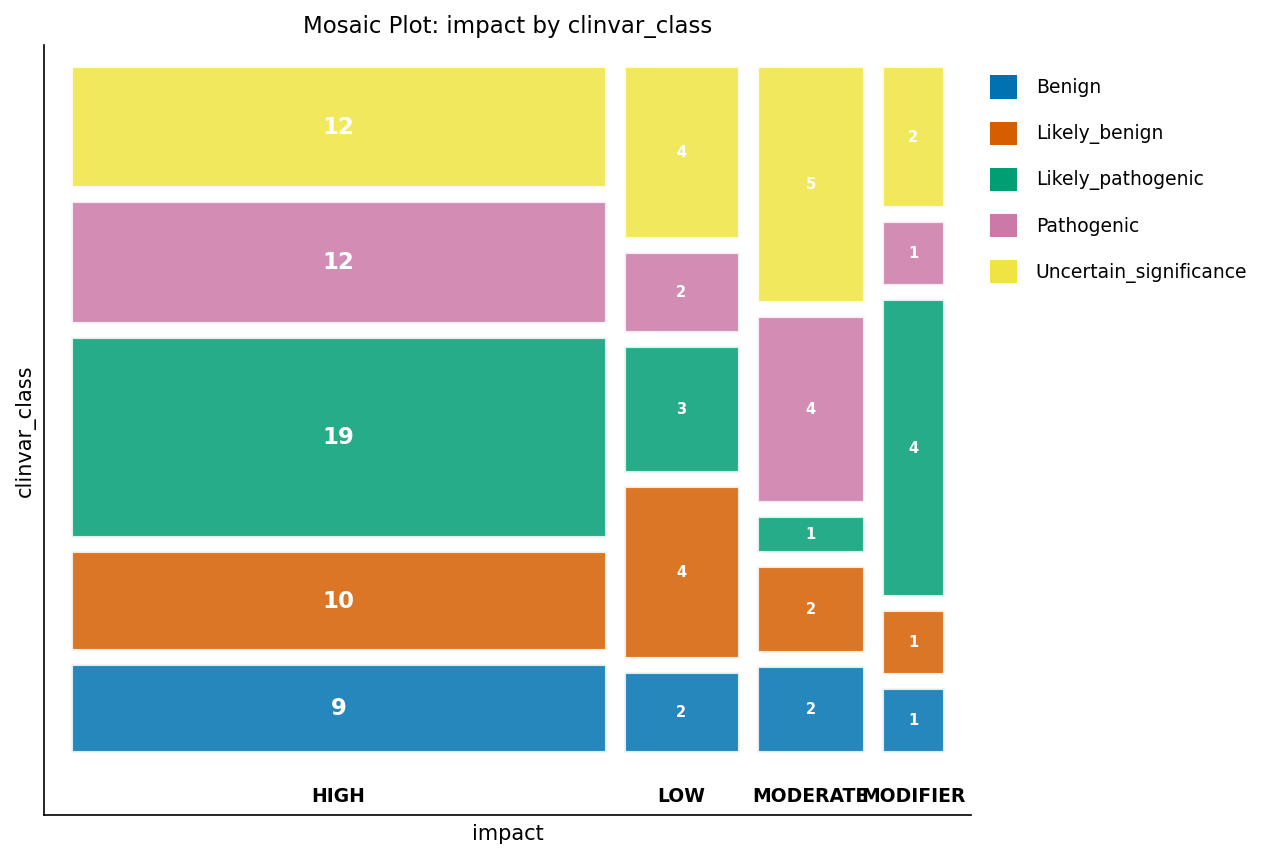

In [4]:
/* --------------------------------------------------------
   Basis-Zusammenfassung der Variantenannotation
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    TITEL 'Varianten-Auswirkung nach ClinVar-Klassifikation';
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=quality_metrics n mean MIN MAX;
    VAR mean_coverage ti_tv_ratio contamination_est;
    TITEL 'Zusammenfassung der Sequenzierungs-Qualitätsmetriken';
AUSFÜHREN;

---

                                  Zusammenfassung der Sequenzierungs-Qualitätsmetriken                                  

                                  Zusammenfassung der Sequenzierungs-Qualitätsmetriken                                  




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


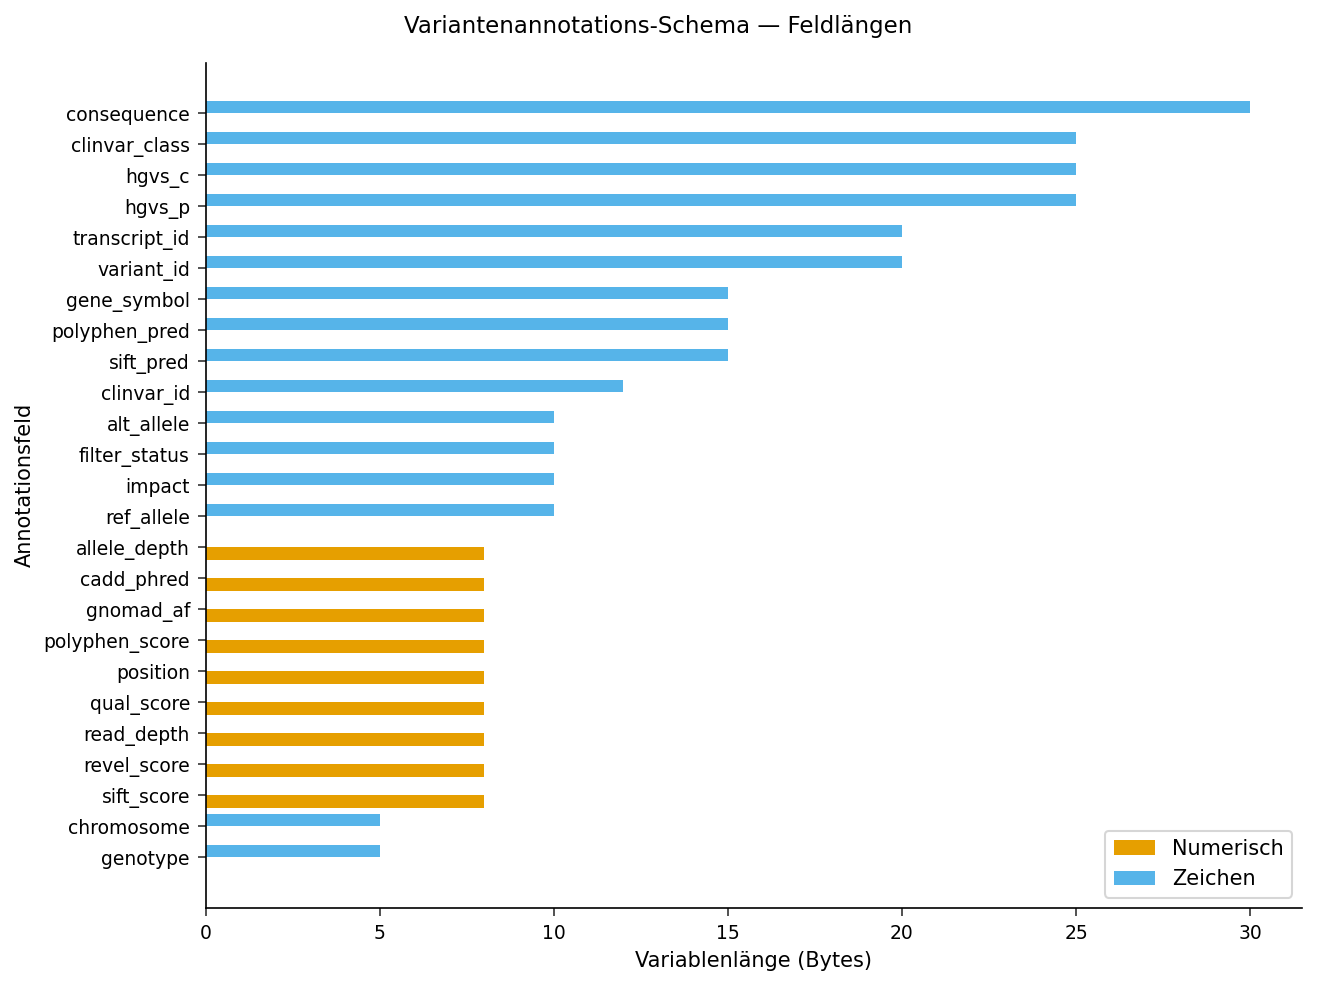

In [5]:
/* --------------------------------------------------------
   Verteilung von Variablentyp und -länge.
   Die Schema-Metadaten mit PROC CONTENTS OUT= erfassen,
   dann die Feldlängen nach Typ plotten. Die TYPE-Codes
   bilden 1 -> Numerisch, 2 -> Zeichen für die Legende ab.
   -------------------------------------------------------- */
PROZEDUR INHALT DATEN=variant_annotations out=schema_lengths NOPRINT;
AUSFÜHREN;

DATEN schema_lengths;
    FESTLEGEN schema_lengths;
    LÄNGE type_label $9;
    WENN TYPE = 1 DANN type_label = 'Numerisch';
    SONST type_label = 'Zeichen';
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=schema_lengths;
    HBAR NAME / RESPONSE=LENGTH GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS BEZEICHNUNG='Variablenlänge (Bytes)';
    YAXIS BEZEICHNUNG='Annotationsfeld';
    TITEL 'Variantenannotations-Schema — Feldlängen';
AUSFÜHREN;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: Das vollständige Variantenannotations-
   Schema dokumentieren — Typen, Längen, Beschriftungen
   für alle 25 Felder. Die Variablen-Metadaten mit OUT=
   erfassen, damit nachgelagerte Schritte das Schema
   programmatisch validieren können.
   -------------------------------------------------------- */
PROZEDUR INHALT DATEN=variant_annotations out=variant_schema NOPRINT;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=variant_schema;
    VAR NAME TYPE LENGTH VARNUM LABEL;
    TITEL 'Variantenannotations-Datenmenge — Vollständiges Schema';
AUSFÜHREN;

                                  Zusammenfassung der Sequenzierungs-Qualitätsmetriken                                  

                                 Variantenannotations-Datenmenge — Vollständiges Schema                                 

  Obs            NAME  TYPE  LENGTH  VARNUM                           LABEL
    1  allele_depth       1       8      22  Alternativallel-Tiefe
    2  alt_allele         2      10       5  Alternativallel
    3  cadd_phred         1       8      19  CADD-Phred-Score
    4  chromosome         2       5       2  Chromosom
    5  clinvar_class      2      25      13  ClinVar-Klassifikation
    6  clinvar_id         2      12      14  ClinVar-Zugangsnummer
    7  consequence        2      30       8  Sequence-Ontology-Konsequenz
    8  filter_status      2      10      25  Filterstatus
    9  gene_symbol        2      15       6  HGNC-Gensymbol
   10  genotype           2       5      21  Proben-Genotyp
   11  gnomad_af          1       8      12  gno


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: Gen-Panel-Schema dokumentieren
   -------------------------------------------------------- */
PROZEDUR INHALT DATEN=gene_panel out=panel_schema NOPRINT;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=panel_schema;
    VAR NAME TYPE LENGTH VARNUM LABEL;
    TITEL 'Gen-Panel-Definition — Schema';
AUSFÜHREN;

                                 Variantenannotations-Datenmenge — Vollständiges Schema                                 

                                             Gen-Panel-Definition — Schema                                              

  Obs                 NAME  TYPE  LENGTH  VARNUM                   LABEL
    1  chromosome              2       5       3  Chromosom
    2  disease_association     2      50       7  Assoziierte Erkrankung
    3  end_pos                 1       8       5  Gen-Endposition
    4  gene_name               2      60       2  Vollständiger Genname
    5  gene_symbol             2      15       1  HGNC-Gensymbol
    6  inheritance             2       5       8  Vererbungsmuster
    7  panel_name              2      30       6  Klinisches Gen-Panel
    8  start_pos               1       8       4  Gen-Startposition




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: QC-Metriken-Schema dokumentieren
   -------------------------------------------------------- */
PROZEDUR INHALT DATEN=quality_metrics out=qc_schema NOPRINT;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=qc_schema;
    VAR NAME TYPE LENGTH VARNUM LABEL;
    TITEL 'Sequenzierungs-Qualitätsmetriken — Schema';
AUSFÜHREN;

                                             Gen-Panel-Definition — Schema                                              

                                       Sequenzierungs-Qualitätsmetriken — Schema                                        

  Obs               NAME  TYPE  LENGTH  VARNUM                                   LABEL
    1  contamination_est     1       8      10  Geschätzte Kontamination
    2  het_hom_ratio         1       8       9  Het/Hom-Verhältnis
    3  mean_coverage         1       8       4  Mittlere Ziel-Coverage
    4  pct_target_100x       1       8       6  Prozent Basen >= 100x
    5  pct_target_20x        1       8       5  Prozent Basen >= 20x
    6  platform              2      15       3  Sequenzierungsplattform
    7  qc_status             2      10      11  QC-Bestanden/Fehlgeschlagen-Status
    8  run_id                2      12       2  Sequenzierungslauf-ID
    9  sample_id             2      15       1  Proben-Kennung
   10  ti_tv_ratio           1 


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Schemavalidierung: prüfen, dass die Annotationsfelder
   die Pipeline-Anforderungen für die ACMG-Interpretation
   erfüllen. Liest die PROC CONTENTS OUT=-Metadaten, wobei
   TYPE=1 numerisch und TYPE=2 Zeichen bedeutet.
   -------------------------------------------------------- */
DATEN schema_validation;
    FESTLEGEN variant_schema;
    LÄNGE requirement $60 status $10;
    /* Numerische Score-Felder müssen numerisch (TYPE=1) gespeichert sein */
    WENN NAME in ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        UND TYPE ne 1 DANN AUSFÜHRUNG;
        requirement = 'Muss für Score-Schwellen numerisch sein';
        status = 'FAIL';
    ENDE;
    SONST WENN NAME in ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        UND TYPE = 1 DANN AUSFÜHRUNG;
        requirement = 'Numerischer Typ bestätigt';
        status = 'PASS';
    ENDE;
    /* ClinVar-Klasse benötigt ausreichende Zeichenlänge */
    SONST WENN NAME = 'clinvar_class' UND LENGTH < 25 DANN AUSFÜHRUNG;
        requirement = 'Mind. $25 für vollständigen Klassifikationstext';
        status = 'FAIL';
    ENDE;
    SONST WENN NAME = 'clinvar_class' DANN AUSFÜHRUNG;
        requirement = 'Zeichenlänge ausreichend';
        status = 'PASS';
    ENDE;
    /* Jedes Feld muss für das Data Dictionary eine Beschriftung tragen */
    SONST WENN LABEL = '' DANN AUSFÜHRUNG;
        requirement = 'Beschriftung für Data Dictionary erforderlich';
        status = 'FAIL';
    ENDE;
    SONST AUSFÜHRUNG;
        requirement = 'Allgemeine Validierung';
        status = 'PASS';
    ENDE;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=schema_validation;
    VAR NAME TYPE LENGTH LABEL requirement status;
    TITEL 'ACMG-Pipeline-Schemavalidierungsbericht';
AUSFÜHREN;

                                        ACMG-Pipeline-Schemavalidierungsbericht                                         

  Obs            NAME  TYPE  LENGTH                           LABEL                 requirement  status
    1  allele_depth       1       8  Alternativallel-Tiefe           Numerischer Typ bestätigt   PASS
    2  alt_allele         2      10  Alternativallel                 Allgemeine Validierung      PASS
    3  cadd_phred         1       8  CADD-Phred-Score                Numerischer Typ bestätigt   PASS
    4  chromosome         2       5  Chromosom                       Allgemeine Validierung      PASS
    5  clinvar_class      2      25  ClinVar-Klassifikation          Zeichenlänge ausreichend    PASS
    6  clinvar_id         2      12  ClinVar-Zugangsnummer           Allgemeine Validierung      PASS
    7  consequence        2      30  Sequence-Ontology-Konsequenz    Allgemeine Validierung      PASS
    8  filter_status      2      10  Filterstatus           


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Interpretation

Das Variantenannotations-Schema enthält 25 Felder, die genomische Koordinaten, funktionale Vorhersagen, Populationsfrequenzen und probenbezogene Qualitätsindikatoren umfassen. Alle neun numerischen Score-Felder (gnomAD-Allelfrequenz, SIFT, PolyPhen-2, CADD, REVEL, Qualitätsscore, Allel-Tiefe, Read-Tiefe und genomische Position) sind korrekt als numerisch typisiert, sodass die ACMG-Interpretations-Engine schwellenbasierte Filterung ohne Typumwandlung anwenden kann. Das Feld clinvar_class mit $25 fasst die längste ClinVar-Klassifikationszeichenkette (Uncertain_significance mit 22 Zeichen). Jedes Annotationsfeld trägt eine beschreibende Beschriftung und erfüllt damit das Data-Dictionary-Gebot des klinischen Labors gemäß den CAP-Akkreditierungsanforderungen. Das Gen-Panel-Schema bildet 15 Krebsprädispositionsgene mit Vererbungsmustern und Krankheitsassoziationen ab und liefert den Referenzrahmen für die Varianten-zu-Gen-Annotation. Die Datenmenge der Sequenzierungs-QC-Metriken dokumentiert 50 Proben über 5 Läufe, mit Kontaminationsschätzungen und Coverage-Schwellen, die die Zuverlässigkeit des Variant-Callings steuern. Dieses Schemadokumentations-Paket unterstützt das Validierungsdossier des Labors für die Einreichung beim New York State CLEP.

---

In [10]:
/* --------------------------------------------------------
   Schemadokumentation und Validierungsbericht für die
   Laborakkreditierung exportieren
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>